

# Word2Vec Tutorial

Obs.: cópia adaptada (corrigida) de https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the Dataset + Text Preprocessing

In [156]:
dataset = pd.read_csv('tweets.csv', encoding='latin1')

In [157]:
dataset

,Unnamed: 0,text
0,0,qnd meu mundo colide com a caipirinha de 5 reais
1,1,isso vai dar um rolo da porra fica vendo
2,2,@camilanks n creio q perdi
3,3,@camilanks entrou alcool saiu historia?
4,4,"@marthuritor ah nao entendi, eu nÃ£o reconheÃ§..."
...,...,...
3485,3485,@freakyliterary Ã tremendamente horrivel
3486,3486,justo hj o cafÃ© acaba como vou viver sem
3487,3487,"@bratydz Entendo, eu acreditava em papai noel ..."
3488,3488,@bratydz Ã meu unico sonho aquele que acabari...


Very basic text preproccessing by removing punctuations, numbers. We have also cleaned the data by removing characters including and after 'https' in the text.

In [158]:
import re
texts=[]
for i in range(0,len(dataset)):
  text = re.sub('[^a-zA-Z]', ' ', str(dataset['text'][i]))
  text = text.lower()
  text = text.split()
  x = len(text) if text.count('https') ==0  else text.index('https')
  text = text[: x ]
  text = [t for t in text if not t=='https']
  text = ' '.join(text)
  texts.append(text)


Size of the dataset.

In [159]:
print(len(texts))

3490


In [160]:
sentences = [line.split() for line in texts]
print(sentences[20:24])

[['clorisacoriza', 'evil', 'asio', 'eu', 'tenho', 'certeza', 'q', 'o', 'post', 'apagado', 'era', 'de', 'jaiana'], ['evil', 'asio'], ['evil', 'asio', 'eu', 'sei'], ['ser', 'que', 'existe', 'tempo', 'e', 'saude', 'no', 'mundo', 'pra', 'tudo', 'que', 'eu', 'quero', 'fazer', 'e', 'n', 'o', 'fa', 'o']]


## Training the word2vec model

In [161]:
! pip install gensim scikit-learn

In [162]:
from gensim.models import Word2Vec


Running the Word2Vec model

In [163]:

# sentences	- List of tokenized sentences	[['i','like','cats']]
# vector_size	- Embedding dimension	100	Word vector length
# window	- Context window size
# epochs	- Training passes over training data
# min_count	- Min frequency to include a word
# sg	0 = CBOW, 1 = Skip-gram	0	Model type
w2v = Word2Vec(sentences, vector_size=300, window=200, epochs=200, min_count=1, sg=0)

In [164]:
print(sentences[20:24])

[['clorisacoriza', 'evil', 'asio', 'eu', 'tenho', 'certeza', 'q', 'o', 'post', 'apagado', 'era', 'de', 'jaiana'], ['evil', 'asio'], ['evil', 'asio', 'eu', 'sei'], ['ser', 'que', 'existe', 'tempo', 'e', 'saude', 'no', 'mundo', 'pra', 'tudo', 'que', 'eu', 'quero', 'fazer', 'e', 'n', 'o', 'fa', 'o']]


## Working with word2vec

Finding the vocabulary of the model can be useful in several general applications, and in this case, provides us with a list of words we can try and use other functions.

In [165]:
# words = list(w2v.wv.vocab)
words = w2v.wv.index_to_key

print(words)

['o', 'de', 'e', 'a', 'eu', 'q', 'bratydz', 'twithcinnamon', 'n', 'um', 'pra', 'com', 'do', 'da', 'no', 'uma', 'vc', 'me', 'que', 'em', 'na', 'se', 'yungfreudian', 'nao', 'mt', 'minha', 'ta', 'isso', 'ai', 'tem', 'meu', 'mas', 'pq', 'vou', 'por', 'so', 's', 'vai', 'dia', 'to', 'velene', 'ele', 'msm', 'essa', 'mais', 'ser', 'calourinda', 'bom', 'esse', 'fazer', 'shreksegundo', 'qnd', 'rt', 'omgmirrorball', 'ela', 'como', 'foi', 'timelessfoolish', 'cara', 'tu', 'ja', 'pqp', 'h', 'ou', 'camikabeo', 'tdlasso', 'wwkalon', 'iyismpvvvvv', 'oq', 'ter', 'tenho', 'os', 'sem', 'tb', 'realmadu', 'bardi', 'ne', 'aq', 'era', 'agora', 'bem', 'v', 'tudo', 'casa', 'tava', 'nada', 'as', 'sei', 'beatriz', 'yourfwnightmare', 'po', 'sou', 'seu', 'nem', 'vez', 'queria', 'vida', 'te', 'ver', 'vntrrl', 'boa', 'pode', 'coisa', 'pro', 'abeactress', 'hj', 'ate', 'vsf', 'ainda', 'la', 'm', 'bibichurros', 'pfv', 'pelo', 'todo', 'guicamorim', 'snowonthealps', 'ludfuckingmila', 'sobre', 'acho', 'foda', 'sim', 'nessa

In [166]:
print(len(words))

6049


Finding the embedding of a given word can be useful when we’re trying to represent sentences as a collection of word embeddings, like when we’re trying to make a weight matrix for the embedding layer of a network.

In [167]:
print(w2v.wv['rolo'] )

[-7.82330614e-03  2.44075149e-01  3.41245115e-01  2.16878280e-01
 -2.24923983e-01  4.45054919e-02 -1.96522404e-03  1.12028852e-01
  2.77429186e-02 -5.59220798e-02  1.36847794e-01 -1.15064822e-01
 -4.26490843e-01  1.09437406e-01 -2.58982807e-01 -2.36210361e-01
 -5.99472150e-02 -1.23780794e-01  1.35613099e-01 -1.74644098e-01
 -1.84418231e-01  7.75282783e-03  6.49162605e-02  1.20381534e-01
  7.25621656e-02  1.49006590e-01 -3.37174684e-01 -1.20768338e-01
 -7.84884915e-02 -1.11463666e-01  1.35021895e-01 -8.28655995e-03
 -1.78679638e-02  3.81846160e-01 -1.57581896e-01  2.52882183e-01
  7.25003630e-02 -2.34084547e-01  7.91755691e-02  9.98724159e-03
  3.80122080e-03 -1.38894215e-01 -1.05890341e-01 -4.89090607e-02
 -2.21549556e-01 -2.91184448e-02  4.73794155e-02 -2.80593634e-01
  7.62020797e-02  3.58647376e-01  3.18052657e-02 -1.00608297e-01
  4.24949005e-02  3.11595321e-01  9.34606940e-02  2.08624348e-01
  3.80274236e-01  1.23677336e-01  2.11107671e-01 -1.69454217e-01
  9.72705409e-02 -3.13342

We can also find out the similarity between given words (the cosine distance between their vectors).

In [168]:
w2v.wv.similarity('cin', 'recife')

np.float32(0.068777636)

With the gensim, we can also find the most similar words to a given word.

In [169]:
print(w2v.wv.most_similar('caba'))

[('endoidar', 0.6175716519355774), ('angustias', 0.45304393768310547), ('sintetizar', 0.4510902762413025), ('imbecil', 0.4213258922100067), ('acontecer', 0.41113200783729553), ('embalagem', 0.39796918630599976), ('lacrada', 0.39108818769454956), ('bolo', 0.38247084617614746), ('pia', 0.38219356536865234), ('hoje', 0.38091346621513367)]


In [170]:
print(w2v.wv.most_similar('gay'))

[('urb', 0.6881235837936401), ('arq', 0.6861847043037415), ('ousada', 0.6716428399085999), ('fetiche', 0.6663805246353149), ('situacoes', 0.654999315738678), ('calourada', 0.6496349573135376), ('cagar', 0.6468937397003174), ('aaaaaaaaaaaaaaaaaa', 0.6437768936157227), ('bromance', 0.6163322925567627), ('paginasemnome', 0.6153643727302551)]


## Visualising word vectors

In [171]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def display_pca_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.wv.key_to_index.keys()), sample)
        else:
            words = [ word for word in model.vocab ]

    # word_vectors = np.array([model[w] for w in words])
    word_vectors = np.array([model.wv[w] for w in words])

    twodim = PCA().fit_transform(word_vectors)[:,:2]

    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y+0.05, word)

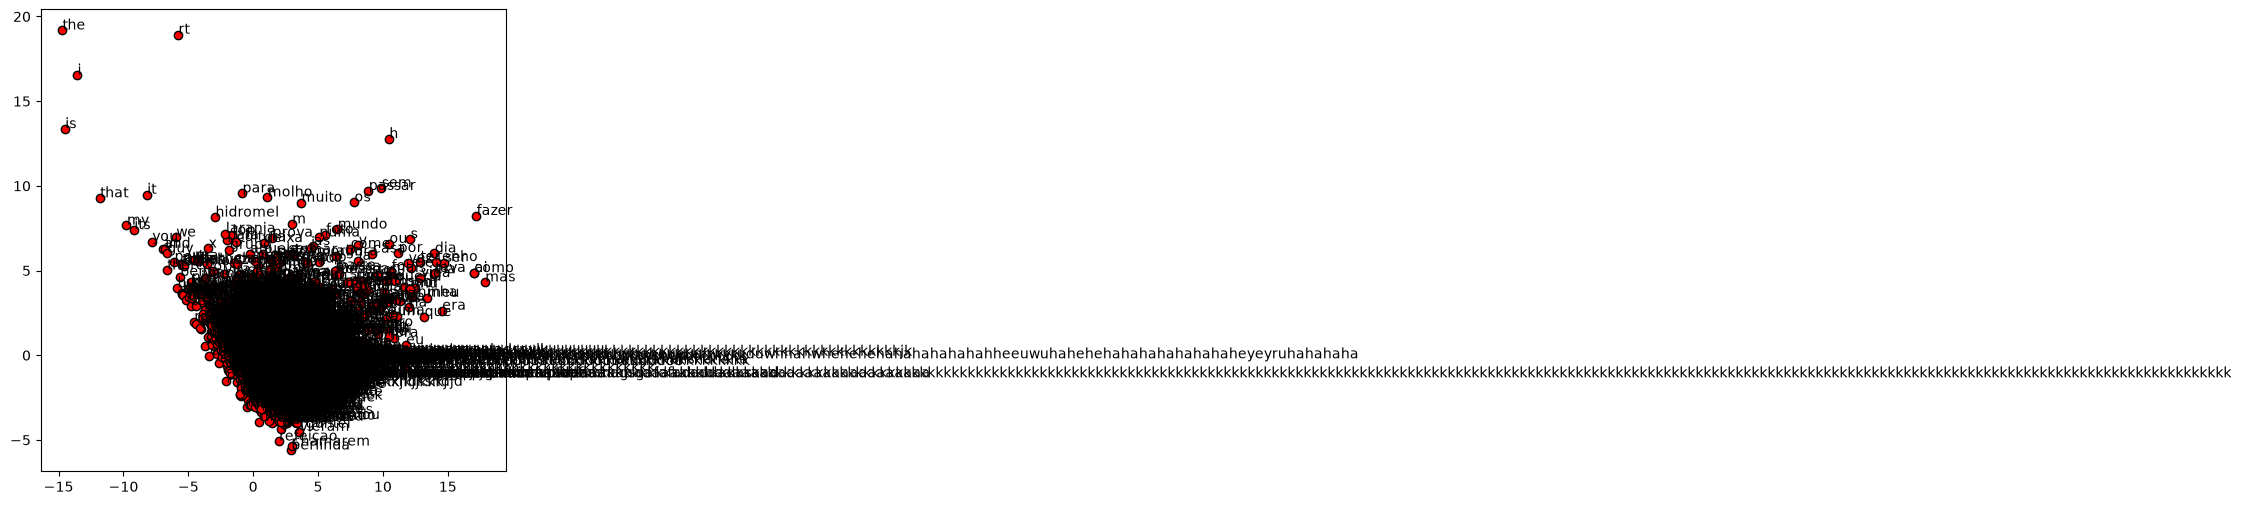

In [172]:
display_pca_scatterplot(w2v,words)

In [173]:
display_pca_scatterplot(w2v, ['palavras', 'para', 'plotar'])

KeyError: "Key 'plotar' not present"